# Housing Price Prediction

## Goal: Predict House Price in Californian Districts

This is supervised learning task because the model trained with labeled data. This is Univariate Regression problem because we try to predict single value. This project use RMSE as a performance meassure. RMSE is more sensitive to outlier than MAE, so it is good if the outlier is very rare.

In [1]:
# Mount Google Drive and add the project directory to the system path
from google.colab import drive
import sys

BASE_PATH = "Machine Learning/Housing Price Prediction"

drive.mount('/content/drive')
sys.path.append(f'/content/drive/My Drive/{BASE_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Download Data

Step:
1. Download data from github
2. Quick look at the data
3. Create test set (use StratifiedSampling)  

Things to note before create test set:  
a. Create a test set early and keep it untouched    
b. Use random sampling with reproducible seeds  
c. Stratified sampling for representative splits  
d. Use stable hash-based splitting if data keep changing  

In this project, I use Stratified Sampling with income category because it is important attribute and must be representative. I also dont use hash-based splitting because the data is static.

### 1.1 - Download data from github

In [2]:
from pathlib import Path
import urllib.request
import tarfile
import pandas as pd

def load_data():
    filepath = Path(f"{BASE_PATH}/data/housing.tgz")  # where to store the data file
    if not filepath.is_file():  # check if the file already exists
        Path(f"{BASE_PATH}/data").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, filepath)
    with tarfile.open(filepath) as current_file:
        current_file.extractall(f"{BASE_PATH}/data")
    return pd.read_csv(f"{BASE_PATH}/data/housing/housing.csv")

housing_data = load_data()

/tmp/ipython-input-4079326860.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  current_file.extractall(f"{BASE_PATH}/data")


### 1.2 - Quick look at the data

In [3]:
# Display the first 5 rows of the dataset
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# Display information about the dataset
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# We can see that the "ocean_proximity" column type 'object', indicating it contains categorical data
# Check the unique values in the "ocean_proximity" column
housing_data["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [6]:
# Display statistical summary of the dataset (count, mean, std, min, 25%, 50%, 75%, max)
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


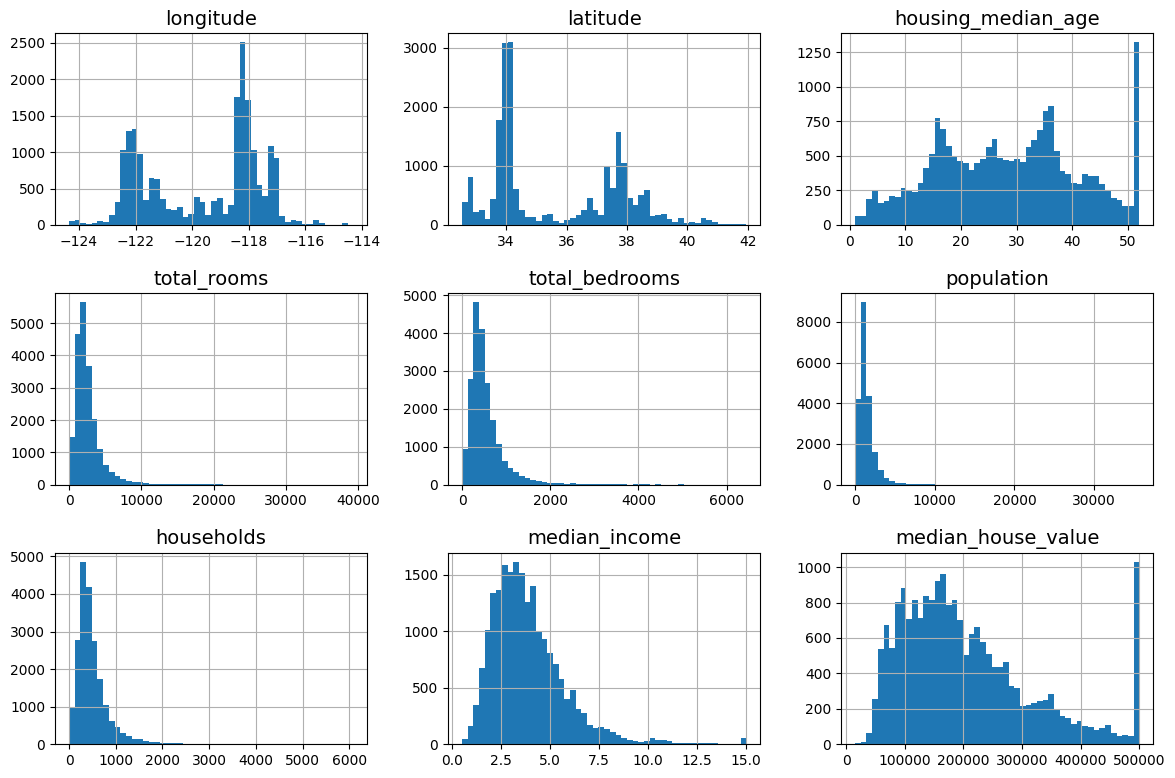

In [7]:
from utils import save_fig
import matplotlib.pyplot as plt

# Set the default figure size and font sizes for better readability
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing_data.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")
plt.show()

### 1.3 - Create test set (use StratifiedSampling)

In [8]:
# Create new column for income categorys based on median_income
import numpy as np

housing_data["income_category"] = pd.cut(housing_data["median_income"],
                                         bins=[0., 1.5, 3.0, 4.5, 6, np.inf],
                                         labels=[1, 2, 3, 4, 5])

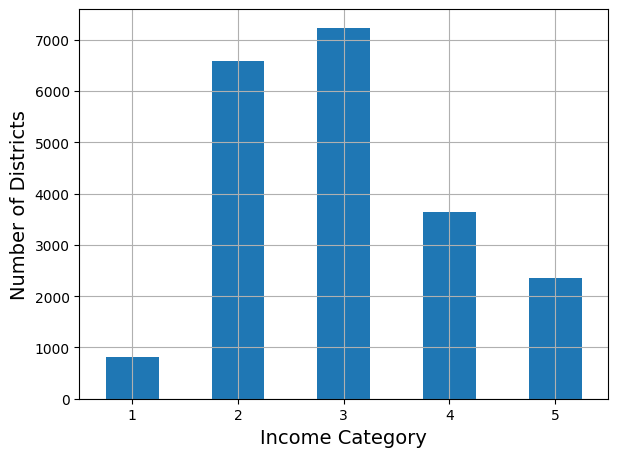

In [9]:
# Display histogram of income categories
housing_data["income_category"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income Category")
plt.ylabel("Number of Districts")
save_fig("income_category_bar_plot")
plt.show()

In [10]:
# Get a single stratified train/test split based on income category
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    housing_data, test_size=0.2, stratify=housing_data["income_category"], random_state=42)

## 2. Explore and Visualize the Data to Gain Insight

Step:
1. Visualizing geographical data  
Insight: Housing price are related to the location and population density (close to ocean and higher population tend to have higher prices)
2. Looking for correlations  
Insight: Median income is the most promising attribute to predict housing median value
3. Experiment with attribute combinations
Insight: We can combine some attributes to make it more useful (room_per_household, bedroom_per_room, population_per_household)

In [11]:
# Use copy() to avoid modifying the original data
strat_train_set_copy = strat_train_set.copy()

### 2.1 - Visualizing geographical data

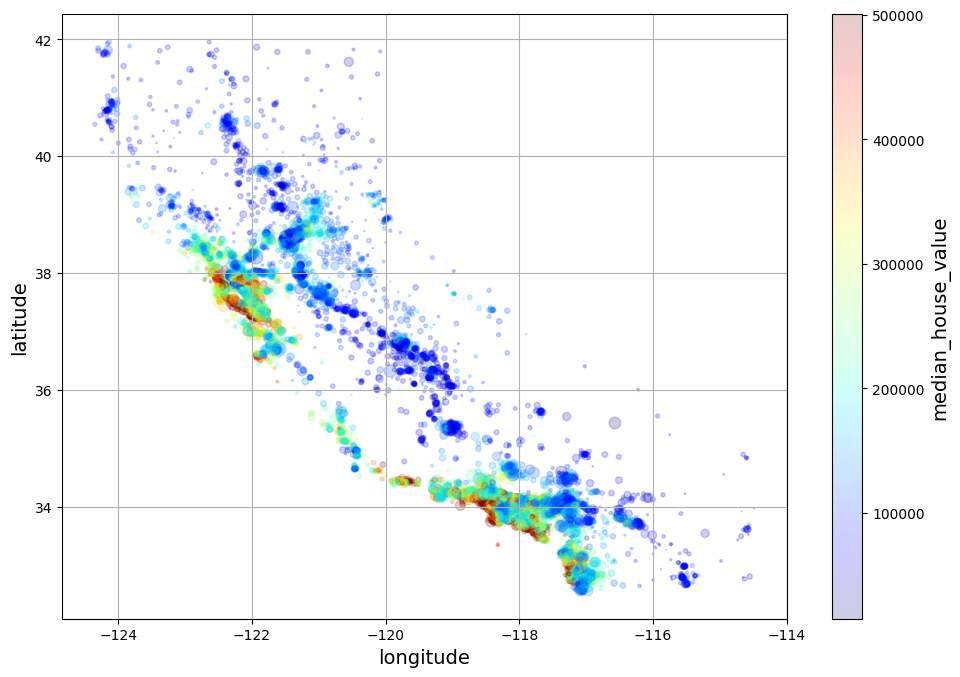

In [12]:
# Plot the geographical data points
strat_train_set_copy.plot(
    kind="scatter", 
    x="longitude", 
    y="latitude", 
    alpha=0.2,  # Transparency represents population density
    s=strat_train_set_copy["population"] / 100,  # Size (s) of each circle represents the district's population
    c="median_house_value",  # Color (c) represents the price (blue: low, red: high)
    cmap="jet", 
    colorbar=True,
    grid=True,
    figsize=(10,7))

save_fig("housing_prices_scatter_plot")
plt.show()

### 2.2 - Look for correlations

In [13]:
# Compute the correlation between each pair of attributes
correlation_matrix = strat_train_set_copy.corr(numeric_only=True)
correlation_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


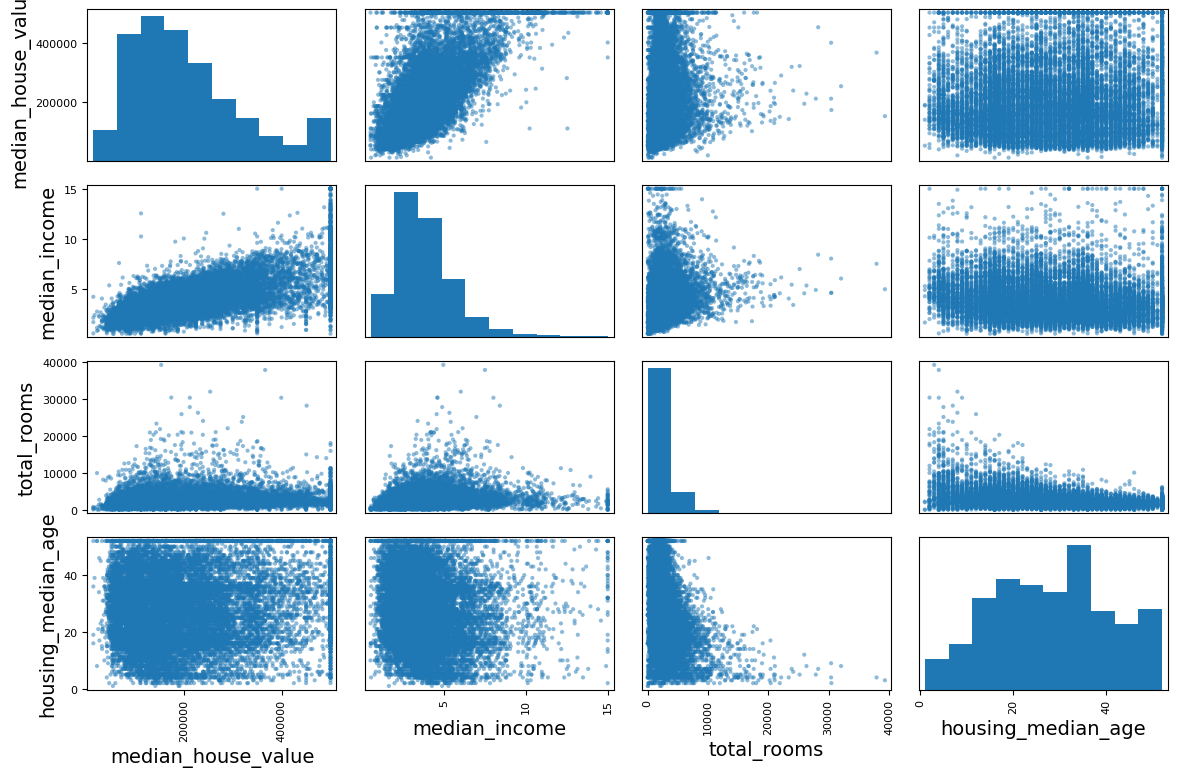

In [14]:
# Plot some promising attributes against the median house value
from pandas.plotting import scatter_matrix

promising_attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(strat_train_set_copy[promising_attributes], figsize=(12, 8))
save_fig("promising_attributes_scatter_matrix")
plt.show()

# We can see that "median_income" is the most promising attribute to predict "median_house_value" (upward trend)

<Axes: xlabel='median_income', ylabel='median_house_value'>

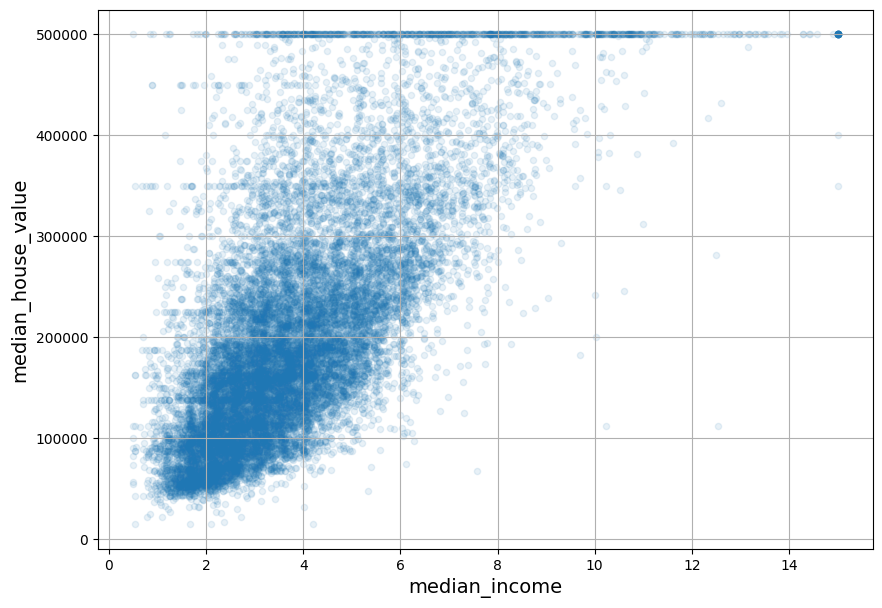

In [15]:
# Plot the most promising attribute against the median house value
strat_train_set_copy.plot(
    kind="scatter", 
    x="median_income", 
    y="median_house_value", 
    alpha=0.1, 
    grid=True,
    figsize=(10,7))

# Insights:
# - There is a clear upward trend, indicating a positive correlation between median income and house value.
# - There is a horizontal line at 500,000, which is likely due to a cap on the maximum house value in the dataset.
# - There are also some horizontal lines at other values (450.000 and 350.000), indicating possible data quality issues.

### 2.3 - Experiment with attribute combinations

In [16]:
# Try a few attribute combinations
strat_train_set_copy["room_per_household"] = strat_train_set_copy["total_rooms"] / strat_train_set_copy["households"]
strat_train_set_copy["bedroom_per_room"] = strat_train_set_copy["total_bedrooms"] / strat_train_set_copy["total_rooms"]
strat_train_set_copy["population_per_household"] = strat_train_set_copy["population"] / strat_train_set_copy["households"]

strat_train_set_copy[["room_per_household", "bedroom_per_room", "population_per_household"]].describe()

,room_per_household,bedroom_per_room,population_per_household
count,16512.000000,16344.000000,16512.000000
mean,5.441010,0.212796,2.995974
std,2.574143,0.057417,4.457373
min,0.888889,0.100000,0.692308
25%,4.443636,0.175257,2.433426
50%,5.235573,0.203106,2.822316
75%,6.053843,0.239421,3.286385
max,141.909091,1.000000,502.461538


In [17]:
# Look at the correlation matrix
correlation_matrix = strat_train_set_copy.corr(numeric_only=True)
correlation_matrix["median_house_value"].sort_values(ascending=False)

# Insights:
# - "room_per_household" has a fairly strong positive correlation with "median_house_value" 
# (higher rooms per household means more room in the house -> higher house value)
# - "bedroom_per_room" has a moderate negative correlation with "median_house_value"
# (higher bedrooms per rooms means smaller house -> lower house value)  

,median_house_value
median_house_value,1.000000
median_income,0.688380
room_per_household,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
population_per_household,-0.038224
longitude,-0.050859


## Prepare the Data for Machine Learning

Step:
1. Set the missing value with SimpleImputer
2. Handling text and categorical attributes with OneHotEncoder
3. Feature scaling and transformation with Standarization
4. Handle population with FunctionTransformer
5. Handle latitude and longtitude with CustomTransformer (use KMeans)

## Use Pipeline to Combine All

## Select and Train a Model

Step:
1. Use LinearRegression, DecisionTree, and Random Forest
2. Use Cross-Validation to get more accurate estimation

## Fine-Tune the Model

Step:
1. Use Randomized Search
2. Analyze the best model
3. Evaluate the model on the test set